In [1]:
import pandas as pd
import os, json

import json, pickle
import random
import numpy as np
from statistics import mean
from scipy.stats import ttest_rel, ttest_ind
import csv
import pandas as pd
import time
from tqdm import tqdm  # for progress bar
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

## Rating score extraction (Human and CLIP)

In [ ]:
"""
Extract rating scores from individual result files from deployed folder and compile them into a single CSV file.
"""
import os
from datetime import datetime
import pandas as pd

formal_dir = "/opt/jinhanz/results/2509_concreteness/deployed/deploy_0818/formal/" # TODO: setup config info file
df_human = pd.DataFrame()

excluded_participants = [ "004", "015", "011", "007", "018", "031", "025", "036", "053", "046", "026", "051", "039", "074","057"]

data_root = "/opt/jinhanz/results/2509_concreteness/results/251215_cogsci_60/"
output_dir = os.path.join(data_root, "human", "ratings")

for b in range(1,5):
    block_dir = os.path.join(formal_dir, f"Block{b}_deploy", "results")
    
    for subject_dir in os.listdir(block_dir):
        subject_path = os.path.join(block_dir, subject_dir)
        if not os.path.isdir(subject_path):
            continue

        if subject_dir[:3] in excluded_participants:
            continue
        
        subject_res_path = os.path.join(subject_path, "RESULTS_FILE.txt")

        if os.path.exists(subject_res_path):
            df = pd.read_csv(subject_res_path, sep='\s+')
            # TODO: assert subject number matches, assert block number matches
            # TODO: readin block order information
            df_human = pd.concat([df_human, df], ignore_index=True)
df_human['answer'] = df_human['answer'] / 100
df_human['image_id'] = df_human['imagename'].apply(lambda x: f"val2014/{'_'.join(x.split('_')[2:])}")
df_human['match'] = df_human['imagename'].apply(lambda x: x.split('_')[0])
df_human['condition'] = df_human['imagename'].apply(lambda x: x.split('_')[1])
df_human.to_csv(os.path.join(output_dir, f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_rating_scores.csv"), index=False)

### Filter by EMHMM group

In [12]:
df_human = pd.read_csv("/opt/jinhanz/results/2509_concreteness/results/251215_cogsci_60/human/ratings/20260112_104651_rating_scores.csv")

In [13]:
import scipy.io as sio
import numpy as np
import pandas as pd
import torch

vbcogroup_hmms = sio.loadmat(os.path.join(data_root, "emhmm", "image", "variables", "vbcogroup_hmms.mat"))

group1_subjs_idx = vbcogroup_hmms['vbco']['groups'][0,0][0,0].squeeze()
group2_subjs_idx = vbcogroup_hmms['vbco']['groups'][0,0][0,1].squeeze()

SubjNames = sio.loadmat(os.path.join(data_root, "emhmm", "image", "variables", "SubjNames.mat"))
SubjNames = SubjNames['SubjNames']

group1_subjs = SubjNames[group1_subjs_idx-1]
group2_subjs = SubjNames[group2_subjs_idx-1]

group1_subjs = np.array(group1_subjs.flatten(), dtype=int)
group2_subjs = np.array(group2_subjs.flatten(), dtype=int)

/tmp/ipykernel_1716002/649269805.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  group1_subjs = np.array(group1_subjs.flatten(), dtype=int)
/tmp/ipykernel_1716002/649269805.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  group2_subjs = np.array(group2_subjs.flatten(), dtype=int)


In [14]:
df_grp1 = df_human[df_human['subject_no'].isin(group1_subjs)]
df_grp2 = df_human[df_human['subject_no'].isin(group2_subjs)]

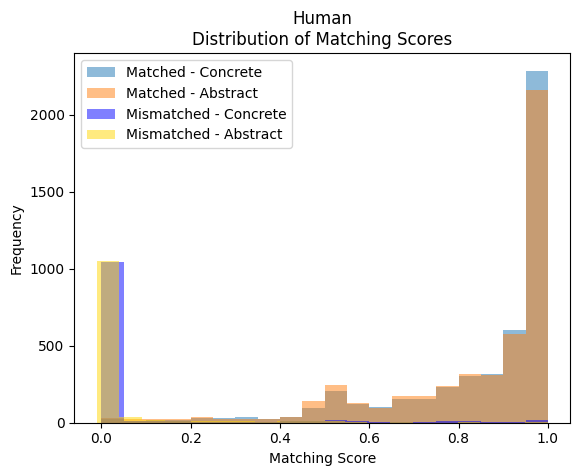

In [15]:
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.hist(df_human[(df_human['match'] == 'mismatched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='blue', alpha=0.5, label='Mismatched - Concrete')
plt.hist(df_human[(df_human['match'] == 'mismatched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='gold', alpha=0.5, label='Mismatched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.title('Human\nDistribution of Matching Scores')
plt.legend()
plt.show()

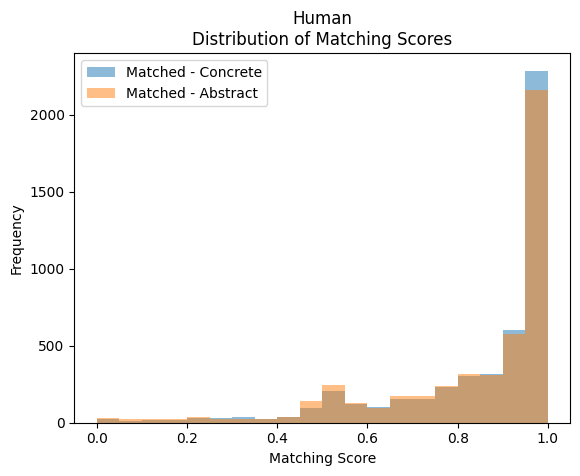

In [16]:
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'con')]['answer'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_human[(df_human['match'] == 'matched') & (df_human['condition'] == 'abs')]['answer'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.title('Human\nDistribution of Matching Scores')
plt.legend()
plt.show()

## Human Model Alignment

In [17]:
experiment = '20250723_193742'

df_clip = pd.read_csv(f"/opt/jinhanz/results/2509_concreteness/stimuli/250602-250723_stimuli_average/{experiment}/captions_and_attributes.csv")
df_clip = df_clip.sort_values(by='image_id')

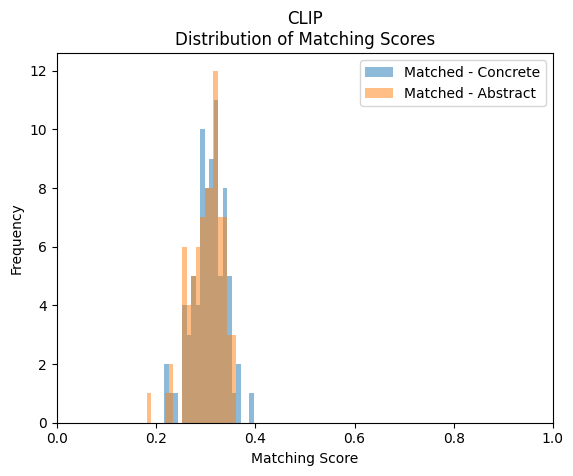

In [18]:
plt.hist(df_clip['con_matching_score'], bins=20, color='tab:blue', alpha=0.5, label='Matched - Concrete')
plt.hist(df_clip['abs_matching_score'], bins=20, color='tab:orange', alpha=0.5, label='Matched - Abstract')
plt.xlabel('Matching Score')
plt.ylabel('Frequency')
plt.xlim(0, 1)
plt.title('CLIP\nDistribution of Matching Scores')
plt.legend()
plt.show()

### Rating Normalization

In [19]:
df_human = df_human[df_human['match'] == 'matched']
df_human['answer_normalized'] = df_human.groupby('subject_no')['answer'].transform(lambda x: (x - x.mean()) / x.std())
df_grp1['answer_normalized'] = df_grp1.groupby('subject_no')['answer'].transform(lambda x: (x - x.mean()) / x.std())
df_grp2['answer_normalized'] = df_grp2.groupby('subject_no')['answer'].transform(lambda x: (x - x.mean()) / x.std())

In [20]:
all_values = pd.concat(
    [df_clip['abs_matching_score'], df_clip['con_matching_score']],
    ignore_index=True
)

mean = all_values.mean()
std = all_values.std()

df_clip['abs_matching_score_normalized'] = (df_clip['abs_matching_score'] - mean) / std
df_clip['con_matching_score_normalized'] = (df_clip['con_matching_score'] - mean) / std

In [21]:
import statsmodels.formula.api as smf

long_format_data = pd.DataFrame()
imgs = df_clip['image_id'].unique()
subjs = df_human['subject_no'].unique()

for i, img in enumerate(imgs):
    for subj in subjs:
        for condition in ["con","abs"]:
            rating_human = df_human[(df_human['image_id'] == img) & (df_human['condition'] == condition) & (df_human['subject_no'] == subj)]['answer_normalized'].values[0]
            rating_clip = df_clip[df_clip['image_id'] == img][f"{condition}_matching_score_normalized"].values[0]
            long_format_data = pd.concat([
                long_format_data,
                pd.DataFrame([{
                    "image": img,
                    "condition": condition,
                    "subject": f"subj_{subj}",
                    "rating_human": rating_human,
                    "rating_clip": rating_clip,
                    "rating_diff": rating_human - rating_clip,
                    "abs_rating_diff": abs(rating_human - rating_clip),
                }])
            ], ignore_index=True)

long_format_data.head()
long_format_data.to_csv("data_rating/rating_diff_long_format.csv", index=False)